# Analysis of Dataset on Different Size Gags Assembled with NERDSS

**Date:** March 27, 2025  
**Author:** yying7@jh.edu  

---

## Input File Naming

The trials run on the **Rockfish supercomputer cluster** are named:

```

\_nerdsslattice\*

```

- The **initial trials** are stored in:

```

\_nerdsslattice0\*
\_nerdsslattice1\*

```

- For some trials, additional simulations varying **S₀** were run. These are stored in:

```

\_nerdsslattice1\*
\_nerdsslattice2\*

```

---

## Theoretical Models

The analysis includes:

- **SGA model**
- **Without SGA model**

[]

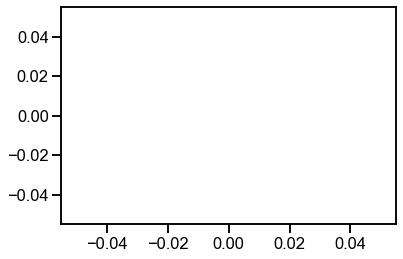

In [30]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import itertools
# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

import seaborn as sns
import os

plt.plot()
sns.set_context("talk")
plt.plot()

# Read and pre-process the dataset

In [31]:
df_results = pd.read_csv("./results/results.csv")

# Reset column names
# EB: bending energy
# EA: area constraint energy
# ER: regularization energy (should converge to near 0)
# Etot: total energy
# MeanForce: mean force on every node
df_results.columns = ['FolderName', 'RelaxArea', 'EB', 'EA', 'ER', 'Etot', 'MeanForce', 'Ngags']

# extracts the last two digits in the name,
# and save in TrialGroup and TrialNum respectively.
# e.g. _fixedmc_01, then TrialGroup is 0 and TrialNum is 1.
# Assuming df_results is already loaded
df_results['SimulationNum'] = df_results['FolderName'].apply(lambda x: int(x[-4:-3]))
df_results['TrialGroup'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) // 10)
df_results['TrialNum'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) % 10)

# Concat Ngags
# Step 1: Work on a copy to preserve original
df_modified = df_results.copy()

# Step 2: Process each group of unique Ngags
for ngag_value in df_modified['Ngags'].unique():
    mask = df_modified['Ngags'] == ngag_value
    group_df = df_modified[mask]
    
    # Get the first TrialGroup value by index
    first_trial_group = group_df['TrialGroup'].iloc[0]
    
    # Apply the fixed TrialGroup to the whole group
    df_modified.loc[mask, 'TrialGroup'] = first_trial_group
    
    # Renumber TrialNum from 1 to len(group)
    df_modified.loc[mask, 'TrialNum'] = range(1, len(group_df) + 1)

# Optional: Convert TrialNum to int
df_modified['TrialNum'] = df_modified['TrialNum'].astype(int)

# Overweite df_results
df_results = df_modified

# Use Ngags as TrialGroup
df_results['TrialGroup'] = df_results['Ngags']
df_results

,FolderName,RelaxArea,EB,EA,ER,Etot,MeanForce,Ngags,SimulationNum,TrialGroup,TrialNum
0,_nerdsslattice0_01,75500.0,495.567,13763.30,0.000000e+00,15018.40,0.185673,227,0,227,1
1,_nerdsslattice0_02,75750.0,501.260,11611.50,0.000000e+00,12825.30,0.170250,227,0,227,2
2,_nerdsslattice0_03,76000.0,496.131,9267.57,0.000000e+00,10373.80,0.133244,227,0,227,3
3,_nerdsslattice0_04,76250.0,494.047,7288.33,0.000000e+00,8269.65,0.127955,227,0,227,4
4,_nerdsslattice0_05,76500.0,504.315,6021.21,6.579100e-29,6886.16,0.084256,227,0,227,5
...,...,...,...,...,...,...,...,...,...,...,...
147,_nerdsslattice3_54,102000.0,108566.000,688874.00,8.893490e+06,35394500.00,27.390800,796,3,796,20
148,_nerdsslattice3_55,106000.0,77522.300,430109.00,9.480660e+06,42369200.00,71.980600,796,3,796,21
149,_nerdsslattice3_56,110000.0,77179.200,144047.00,5.299610e+06,42864900.00,186.849000,796,3,796,22
150,_nerdsslattice3_57,114000.0,112690.000,230777.00,1.390580e+07,51182600.00,2.998960,796,3,796,23


# Define bootstrap test of minimum

In [32]:
"""
(1) group by GagDistance and calculate the minimum bending energy and total energy in each group
(2) in each group, use resampling to calculate error of MINIMUM.
    See the following function docstring for more information.
    
(3) Initiate a plot with two subplots. Plot minimum bending energy on y-axis
    and Gag-Distance on x-axis with a bar plot on the first subplot.
    Use a single-sided errorbar that only goes upwards to show the error of minimum.
(4) Repeat that for total energy on the second subplot.
"""

# Function to perform resampling to estimate error of minimum energy
def resampling_min_error(data, num_samples=10000, confidence=0.95):
    """
    Perform a bootstrap resampling test to estimate the error of the minimum energy in each GagDistance group.
    
    The process involves:
    - Randomly resampling (with replacement) the energy values in the group.
    - Computing the minimum energy for each resampled dataset.
    - Calculating the upper bound error based on a one-sided confidence interval.

    Args:
    - data: The energy values of a given group.
    - num_samples: Number of bootstrap samples to generate.
    - confidence: Confidence level for the upper bound error estimation.

    Returns:
    - The upper error estimate for the minimum energy.
    """
    min_values = []
    for _ in range(num_samples):
        resampled_data = np.random.choice(data, size=len(data), replace=True)
        min_values.append(np.min(resampled_data))
    
    #print(min_values)
    # Compute the one-sided error bound at the given confidence level
    error = np.percentile(min_values, (confidence) * 100) - np.min(data)
    #print(error)
    return error

# Group the data by trial and size and use the bootstrap test

In [33]:
# Group by GagDistance and compute the minimum values
grouped_df = df_results.groupby(["TrialGroup"]).agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

# Unique trial groups
trial_groups = df_results['TrialGroup'].unique()

# Ensure the error columns exist
if 'EB_err' not in grouped_df.columns:
    grouped_df['EB_err'] = None
if 'Etot_err' not in grouped_df.columns:
    grouped_df['Etot_err'] = None
if 'Ngags' not in grouped_df.columns:
    grouped_df['Ngags'] = None
    
    
# Iterate and assign values safely
for trial_group in trial_groups:
    subset_eb = df_results.loc[
        (df_results['TrialGroup'] == trial_group) , "EB"
    ]
    subset_etot = df_results.loc[
        (df_results['TrialGroup'] == trial_group) , "Etot"
    ]

    # Use .loc to assign values safely
    grouped_df.loc[
        (grouped_df['TrialGroup'] == trial_group) , "EB_err"
    ] = resampling_min_error(subset_eb)
    
    grouped_df.loc[
        (grouped_df['TrialGroup'] == trial_group) , "Etot_err"
    ] = resampling_min_error(subset_etot)
    
    # Assign size
    # Just use the first term, assuming all gag lattices are of the same size in the same
    # size and trial group
    grouped_df.loc[
        (grouped_df['TrialGroup'] == trial_group), "Ngags"
    ] = df_results.loc[(df_results['TrialGroup'] == trial_group), "Ngags"].iloc[0]
    

grouped_df

,TrialGroup,EB,Etot,EB_err,Etot_err,Ngags
0,43,16.3511,1.636610e+01,0.2434,0.2433,43
1,65,23.9165,2.393570e+01,0.1926,0.1918,65
2,126,183.2980,1.833090e+02,7.833,7.836,126
3,157,166.2520,1.662660e+02,1.442,1.44,157
4,227,454.9100,4.550210e+02,13.038,13.448,227
5,392,461.6880,5.329370e+02,9.612,86.793,392
6,588,772.8780,2.253440e+03,5.347,100.73,588
7,796,16949.7000,2.395670e+07,11119.2,590200.0,796


# Plot energy versus S_0

Change S_0 for specific tension (); boundary conditions make a big impact.
We can quantify the big impact -> tension remains constant; that is controlled in the cellular environment
All the parameter is controlled.


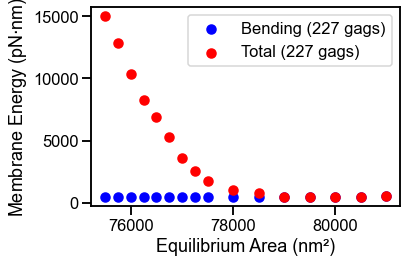

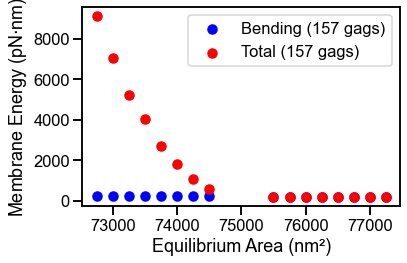

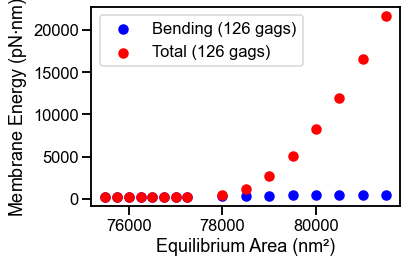

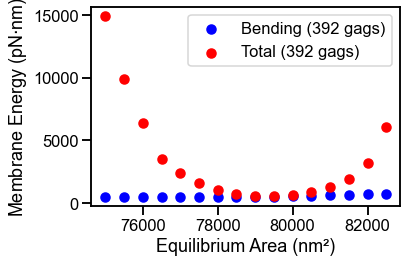

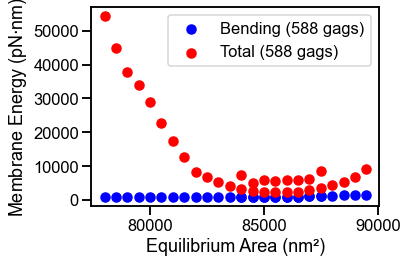

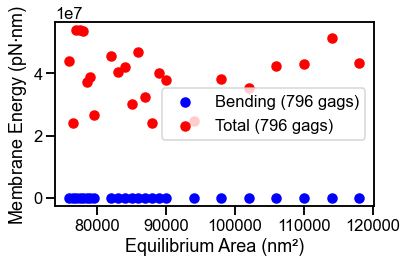

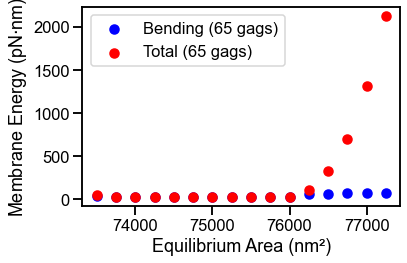

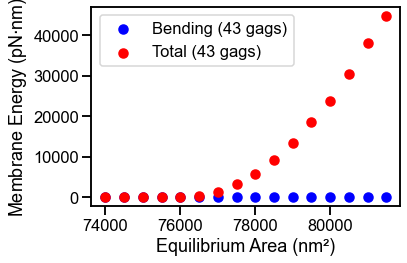

'./svg'

In [6]:
# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Unique trial groups
trial_groups = df_results['TrialGroup'].unique()

# Define superscript format for labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Energy (pN$\cdot$nm)"

# Generate plots for each trial group
for trial_group in trial_groups:
    df_group = df_results[(df_results['TrialGroup'] == trial_group)]

    # Plot EB vs RelaxArea
    plt.figure(figsize=(6, 4))
    plt.scatter(df_group['RelaxArea'], df_group['EB'], color='b',
                label=f'Bending ({trial_group} gags)')

    # Plot Etot vs RelaxArea
    plt.scatter(df_group['RelaxArea'], df_group['Etot'], color='r',
                label=f'Total ({trial_group} gags)')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir,
                             f'TrialGroup_{trial_group}_EB_Etot_vs_RelaxArea.svg'), format='svg')
    plt.show()

# Notify user that the plots are saved
output_dir


# Ignore 796 for now

In [7]:
grouped_df = grouped_df[grouped_df['Ngags'] != 796]
grouped_df

,TrialGroup,EB,Etot,EB_err,Etot_err,Ngags
0,43,16.3511,16.3661,0.2434,0.2433,43
1,65,23.9165,23.9357,0.1926,0.1918,65
2,126,183.2980,183.3090,7.833,7.836,126
3,157,166.2520,166.2660,1.442,1.44,157
4,227,454.9100,455.0210,13.038,13.448,227
5,392,461.6880,532.9370,9.612,86.793,392
6,588,772.8780,2253.4400,5.347,100.73,588


# Plot Etot vs Ngags by Ecc. 

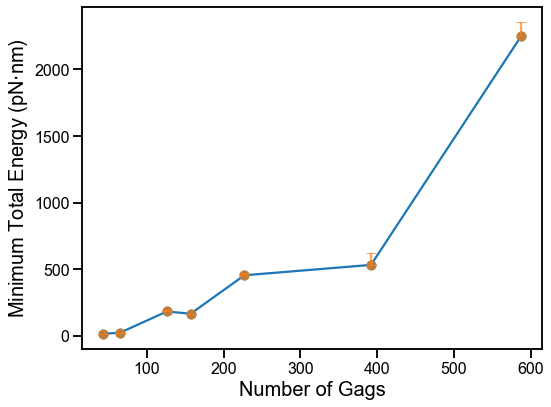

In [8]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

plt.figure(figsize=(8, 6))

# Plot line
plt.plot(grouped_df['Ngags'], grouped_df['Etot'],
         marker='o', linestyle='-')

# Add directed error bars (only top half)
plt.errorbar(grouped_df['Ngags'], grouped_df['Etot'], 
             yerr=[np.zeros_like(grouped_df['Etot_err']), grouped_df['Etot_err']], 
             fmt='o', capsize=5, alpha=0.7)

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_Ngags.svg'), format='svg')

plt.show()


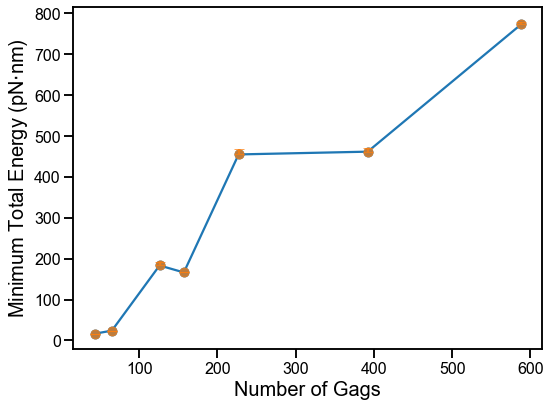

In [9]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

plt.figure(figsize=(8, 6))

# Plot line
plt.plot(grouped_df['Ngags'], grouped_df['EB'],
         marker='o', linestyle='-')

# Add directed error bars (only top half)
plt.errorbar(grouped_df['Ngags'], grouped_df['EB'], 
             yerr=[np.zeros_like(grouped_df['EB_err']), grouped_df['EB_err']], 
             fmt='o', capsize=5, alpha=0.7)

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_Ngags.svg'), format='svg')

plt.show()


# Add a theoretical curve

In [10]:
theory_radius = np.linspace(10, 40, 500)

def theory_function_eb(theory_radius, membrane_cap_spherical_radius = 59.0,
                       gag_cap_spherical_radius = 50.0, kappa = 83.4, rho_R = 135.0):
    """
    Note : small gradient approximation applied
    
    eb theory = 4h /r * pi * kappa = 4 (r - sqrt(r^2 - rho^2)) / r * pi * kappa
    
    eb relax = 8πκ tan^2⁡θ  (ρ_M^2)/(ρ_R^2-ρ_M^2 )
    """
    r = gag_cap_spherical_radius
    rho = theory_radius
    
    eb_cap = 4 * (r - np.sqrt(r**2 - rho**2)) / r * np.pi * kappa
    
    # Add relaxation
    
    tan_theta = theory_radius / np.sqrt(r ** 2 - rho ** 2)
    
    # Use similar triangles to scale up rho to rho_M
    
    rho_M = rho / gag_cap_spherical_radius * membrane_cap_spherical_radius
    
    # Use equation to calculate relaxation energy
    
    eb_relax = 8 * np.pi * kappa * (tan_theta ** 2) * (rho_M ** 2) / (rho_R ** 2 - rho_M ** 2)
    
    return eb_cap, (eb_cap + eb_relax)

# Calculate a no SGA theoretical curve with methods in solve_membrane_shape_bvp_wo_SGA.ipynb

## Note!! The code takes ~15 min to run (on a M1 chip MacOX), load the `.npy` file if no rerun needed

### Define the functions

In [11]:
from scipy.integrate import solve_ivp
from scipy.integrate import solve_bvp
from scipy.interpolate import splrep, PPoly

def solve_membrane_shape(rhoM=10.0, ratioMR=1.0, Rmem=59.0, kappa=83.4,
                         do_plot=False, tolerance=0.001, max_nodes=1000, init_secondderiv=None):
    """
    Solves for the shape of a membrane using a boundary value problem approach.

    Parameters:
        rhoM (float): Membrane cap azimuthal radius.
        ratioMR (float): Azimuthal radius ratio between relaxation region and membrane cap.
        Rmem (float): 3D radius of spherical membrane cap.
        kappa (float): Bending rigidity in pN.nm.
        do_plot (bool): Whether to generate plots for visualization.
        tolerance (float): Convergence tolerance for the solver.
        max_nodes (int): Maximum number of nodes for the solver.
        init_secondderiv (float or None): Initial second derivative. If None, it is computed.
    
    Returns:
        float: The bending energy of the membrane.
    """
    # Compute the initial slope based on given parameters
    init_slope = -rhoM / np.sqrt(Rmem**2 - rhoM**2)
    
    # Compute initial second derivative if not provided
    if init_secondderiv is None:
        init_secondderiv = - Rmem ** 2 / np.power(Rmem ** 2 - rhoM ** 2, 1.5)
    
    def ode_system(x, y):
        """Defines the system of differential equations to solve."""
        h, h1, h2, h3 = y  # Unpacking state variables
        rho = x  # Radial coordinate
        
        # Define h'''' from the governing equation
        f = (-1 / (rho**3 * (1 + h1**2)**2)) * (3 * h1**5 + h1**7 + 3 * rho * h1**6 * h2 
            - rho * (h2 + 3 * rho**2 * h2**3 - 2 * rho * h3) + rho * h1**4 * (5 * h2 + 2 * rho * h3) 
            + rho * h1**2 * (h2 + 21 * rho**2 * h2**3 + 4 * rho * h3)
            + h1 * (1 - 9 * rho**2 * h2**2 - 12 * rho**3 * h2 * h3) 
            - 3 * h1**3 * (-1 + 3 * rho**2 * h2**2 + 4 * rho**3 * h2 * h3))
        
        # Return system of ODEs
        return [y[1], y[2], y[3], f]
    
    def bc(ya, yb):
        """Defines the boundary conditions for the system."""
        return np.array([ya[0], ya[1] - init_slope, ya[2] - init_secondderiv, yb[1]])
    
    # Define the radial range for solving the BVP
    rhoR = rhoM + rhoM * ratioMR
    x = np.linspace(rhoM, rhoR, 1000)
    
    # Initialize solution array
    y_a = np.zeros((4, x.size))
    y_a[1] = 0.0  # Initial guess for the first derivative
    
    # Solve the boundary value problem
    res_a = solve_bvp(ode_system, bc, x, y_a, max_nodes=max_nodes, tol=tolerance)
    
    # Generate plots if required
    if do_plot:
        x_plot = np.linspace(rhoM, rhoR, 1000)
        y_plot_a = res_a.sol(x_plot)[0]
        plt.plot(x_plot, y_plot_a, label='Initial Guess A')
        plt.xlabel(r"$\rho$ (nm)")
        plt.ylabel(r"$h$ (nm)")
        plt.tight_layout()
        plt.legend()
        plt.savefig("hvsr_guesses.eps", format="eps")
        plt.show()
    
    # Compute derivatives of the solution
    y_sol_PPoly = res_a.sol
    y1_sol_PPoly = y_sol_PPoly.derivative()
    y2_sol_PPoly = y1_sol_PPoly.derivative()
    
    # Evaluate derivatives at plot points
    x_plot = np.linspace(rhoM, rhoR, 1000)
    y_plot_a = res_a.sol(x_plot)[0]
    y1_plot = y1_sol_PPoly(x_plot)[0]
    y2_plot = y2_sol_PPoly(x_plot)[0]
    
    if do_plot:
        plt.plot(x_plot, y_plot_a, label='h')
        plt.plot(x_plot, y1_plot, label="h'")
        plt.plot(x_plot, 10 * y2_plot, label="10 h''")
        plt.legend()
        plt.xlabel(r"$\rho$ (nm)")
        plt.show()
    
    def integrand(x):
        """Defines the integrand for bending energy computation."""
        A = (y2_sol_PPoly(x)[0] + y1_sol_PPoly(x)[0] / x + y1_sol_PPoly(x)[0] ** 3 / x) ** 2
        B = (1 + y1_sol_PPoly(x)[0] ** 2) ** 3
        return A / B * x
    
    # Compute bending energy integral
    x_int = np.linspace(rhoM, rhoR, 100000)
    y_int = integrand(x_int)
    tck = splrep(x_int, y_int, s=0)
    p_integrand = PPoly.from_spline(tck)
    
    # Compute bending energy
    eb = p_integrand.integrate(rhoM, rhoR) * np.pi * kappa
    
    if do_plot:
        print(eb)  # Print bending energy if plotting is enabled
    
    return eb

def solve_membrane_shape_auto(init_secondderiv_array = np.linspace(-0.01, 0.06, 30),
                              do_min_plot = False, **kwargs):
    
    eb_array = np.zeros(len(init_secondderiv_array)) # initialize bending energy array
    
    # iterate thru different initial h''
    for (i, init_secondderiv) in enumerate(init_secondderiv_array):
        eb = solve_membrane_shape(init_secondderiv = init_secondderiv, **kwargs)
        eb_array[i] = eb
    
    if do_min_plot:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()
        plt.plot(init_secondderiv_array, eb_array)
        plt.xlabel(r"$h''_{init}$ (nm$^{-1}$)")
        plt.ylabel(r"$E_B$ (pN$\cdot$nm)")
    return min(eb_array)

### Run numerical solution

Takes a while!

In [12]:

rhoGags = np.linspace(10.0, 50.0, 60)

# convert rhoGag to rhoM
rhoMs = rhoGags / 50.0 * 59.0 # assume gag sphere radius = 50.0 nm and lbond = 9.0 nm

# calculate ratio
rhoR = 135.0
ratioMRs = (rhoR - rhoMs) / rhoMs

# initialize record array
ebs = []

'''

for (rhoM, ratioMR) in zip(rhoMs, ratioMRs):
    # print
    print("Iteration Starts")
    
    # solve membrane shape
    eb = solve_membrane_shape_auto(rhoM = rhoM, ratioMR = ratioMR, tolerance = 1e-5, max_nodes = 2000,
                              init_secondderiv_array = np.linspace(-0.1, 0.25, 100))
    ebs.append(eb)
'''

'\n\nfor (rhoM, ratioMR) in zip(rhoMs, ratioMRs):\n    # print\n    print("Iteration Starts")\n    \n    # solve membrane shape\n    eb = solve_membrane_shape_auto(rhoM = rhoM, ratioMR = ratioMR, tolerance = 1e-5, max_nodes = 2000,\n                              init_secondderiv_array = np.linspace(-0.1, 0.25, 100))\n    ebs.append(eb)\n'

In [13]:
# convert to numpy array
#ebs_nparray = np.array(ebs)

# if load needed use this code
ebs_nparray = np.load("relaxation_theory_no_sga.npy")

# print ebs array
print(ebs_nparray)

# save to file
np.save("relaxation_theory_no_sga.npy", ebs_nparray)

[  0.45163372   0.53600517   0.52223136   0.52214487   0.5410264
   0.58465191   0.65927552   0.77160706   0.92878432   1.13834001
   1.40816332   1.74645627   2.12079247   2.23955168   2.44180983
   2.73947005   3.14458793   3.66927671   4.32560545   4.70227231
   5.16583802   5.80355383   6.63037543   7.36149623   8.05650604
   9.00070883  10.05275638  10.95071655  12.17462476  13.31681714
  14.64393061  16.0220849   17.58035181  19.1193097   20.88974126
  22.78951852  24.71479854  26.81146539  29.07190156  31.46782502
  33.97639643  36.72261504  39.62407423  42.65020641  45.96423932
  50.09214118  52.95606189  56.80079586  60.90679589  66.38069571
  72.5615164   74.54756129  81.41382339  91.37306479 102.63156053
 113.43836549 122.17487665 127.4819654  128.38030595   0.        ]


In [14]:
# Get theoretical gag lattice radius
theory_radius = rhoGags

# calculate cap eb with sga, note that with / without sga, the cap shape and energy is the same
theory_eb, theory_eb_add_relax_with_sga  = theory_function_eb(rhoGags) 

# get data for theoretical curve without sga
theory_eb_add_relax = theory_eb + ebs_nparray

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_57927/2482938566.py:19: RuntimeWarning: divide by zero encountered in divide
  tan_theta = theory_radius / np.sqrt(r ** 2 - rho ** 2)


# Convert theory radius to theory ngags

$$
r_M = f_1(n_{\text{gag}}) = r_M \left( \left( 1 - \frac{l_{hg}^2}{2r_M^2} \right) \sqrt{1 - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right)^2} - \left(1 - \frac{2n_{\text{gag}}}{N_{\text{gag}}}\right) \sqrt{1 - \left(1 - \frac{l_{hg}^2}{2r_M^2}\right)^2} \right)
$$

In [15]:
import numpy as np
from scipy.optimize import root_scalar

def calculate_f1(n_gag, r_M, l_hg, N_gag):
    """
    Forward calculation of f1 for a single n_gag value.
    """
    epsilon = (l_hg**2) / (2 * r_M**2)
    term1 = (1 - epsilon)
    sqrt1 = np.sqrt(1 - (1 - (2 * n_gag / N_gag))**2)
    term2 = (1 - (2 * n_gag / N_gag))
    sqrt2 = np.sqrt(1 - (1 - epsilon)**2)
    f1 = r_M * (term1 * sqrt1 - term2 * sqrt2)
    return f1

import numpy as np
from scipy.interpolate import interp1d

def setup_inverse_f1_spline(r_M, l_hg, N_gag, n_gag_resolution=10000):
    """
    Precompute a spline for f1(n_gag) and create an inverse spline.
    
    Returns: (forward_spline, inverse_spline)
    """
    # Create a dense grid of n_gag values
    n_gag_grid = np.linspace(0, N_gag/2.01, n_gag_resolution)
    
    # Forward calculation
    f1_grid = calculate_f1(n_gag_grid, r_M, l_hg, N_gag)
    
    # Create monotonic forward spline: n_gag -> f1
    forward_spline = interp1d(n_gag_grid, f1_grid, kind='cubic', fill_value="extrapolate")
    
    # Create monotonic inverse spline: f1 -> n_gag
    # Important: sort if necessary
    sorted_indices = np.argsort(f1_grid)
    f1_sorted = f1_grid[sorted_indices]
    n_gag_sorted = n_gag_grid[sorted_indices]
    inverse_spline = interp1d(f1_sorted, n_gag_sorted, kind='cubic', fill_value="extrapolate")
    
    return forward_spline, inverse_spline

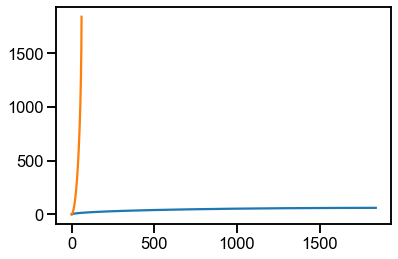

In [26]:
# Setup once
forward_spline, inverse_spline = setup_inverse_f1_spline(r_M=59.0, l_hg=2.35, N_gag=3700)

# Invert fast
theory_ngags = inverse_spline(theory_radius)

plt.plot(forward_spline.x, forward_spline.y)
plt.plot(inverse_spline.x, inverse_spline.y)

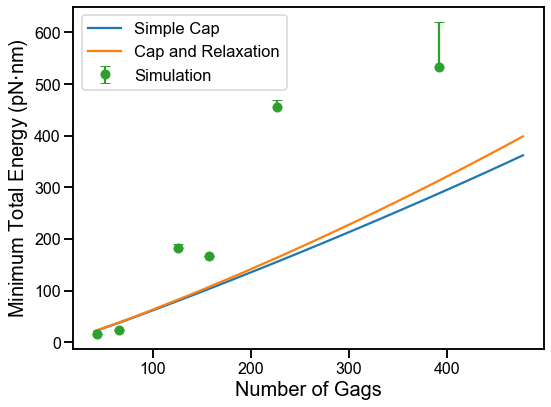

In [28]:

"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

plt.figure(figsize=(8, 6))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Convert theory radius to theory number of gags
#theory_ngags_1 = 3700 * (59.0 - np.sqrt(59.0 ** 2 - theory_radius ** 2)) * 2  / (4 * 59.0)

# Plot theory curves
plt.plot(theory_ngags[:-18], theory_eb[:-18], label = "Simple Cap")
plt.plot(theory_ngags[:-18], theory_eb_add_relax[:-18], label = "Cap and Relaxation")

# Plot theory curves
#plt.plot(theory_ngags_1[:-18], theory_eb[:-18], label = "Simple Cap1")
#plt.plot(theory_ngags_1[:-18], theory_eb_add_relax[:-18], label = "Cap and Relaxation1")

# 

# Add directed error bars (only top half)
plt.errorbar(grouped_df['Ngags'][:-1], grouped_df['Etot'][:-1], 
             yerr=[np.zeros_like(grouped_df['Etot_err'][:-1]), grouped_df['Etot_err'][:-1]], 
             fmt='o', capsize=5, alpha=1.0, label = "Simulation")

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Total Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Etot_vs_Ngags.svg'), format='svg')

plt.show()


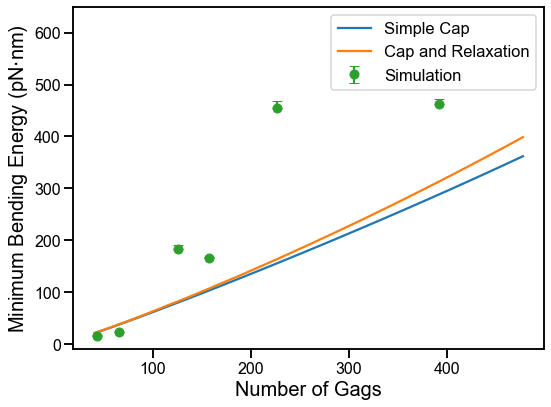

In [29]:

"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data

plt.figure(figsize=(8, 6))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Plot theory curves
plt.plot(theory_ngags[:-18], theory_eb[:-18], label = "Simple Cap")
plt.plot(theory_ngags[:-18], theory_eb_add_relax[:-18], label = "Cap and Relaxation")

# 

# Add directed error bars (only top half)
plt.errorbar(grouped_df['Ngags'][:-1], grouped_df['EB'][:-1], 
             yerr=[np.zeros_like(grouped_df['EB_err'][:-1]), grouped_df['EB_err'][:-1]], 
             fmt='o', capsize=5, alpha=1.0, label = "Simulation")

# Labels and title
plt.xlabel("Number of Gags", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.ylim([-10, 650])
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_Ngags.svg'), format='svg')

plt.show()


# Compare SGAs

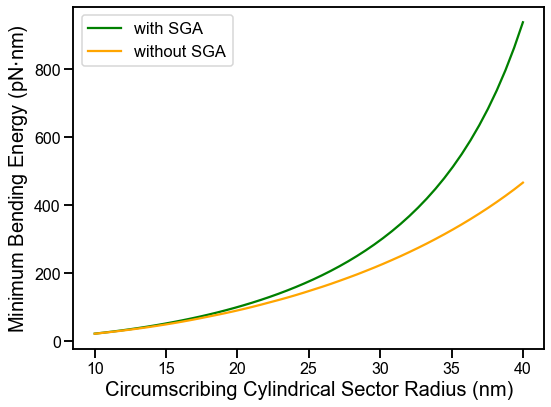

In [43]:
plt.figure(figsize=(8, 6))

# Plot theory curves
# Plot theory curves
plt.plot(theory_radius, theory_eb_add_relax_with_sga, label = "with SGA", c = 'g')
plt.plot(theory_radius, ebs_nparray + theory_eb, label = "without SGA", c = 'orange')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_CCSR_by_Ecc_theory_compare.svg'), format='svg')

plt.show()


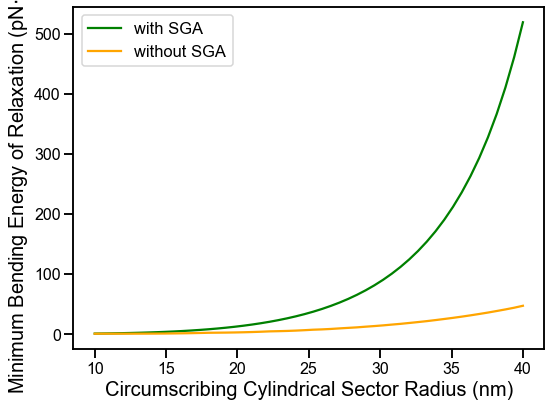

In [42]:
plt.figure(figsize=(8, 6))

# Plot theory curves
# Plot theory curves
plt.plot(theory_radius, theory_eb_add_relax_with_sga - theory_eb, label = "with SGA", c = 'g')
plt.plot(theory_radius, ebs_nparray, label = "without SGA", c = 'orange')

# Labels and title
plt.xlabel("Circumscribing Cylindrical Sector Radius (nm)", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy of Relaxation (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_relax_vs_CCSR_by_Ecc_theory_compare.svg'), format='svg')

plt.show()


# Plot EB vs Ecc. by Ngags

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_17992/1543183702.py:21: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


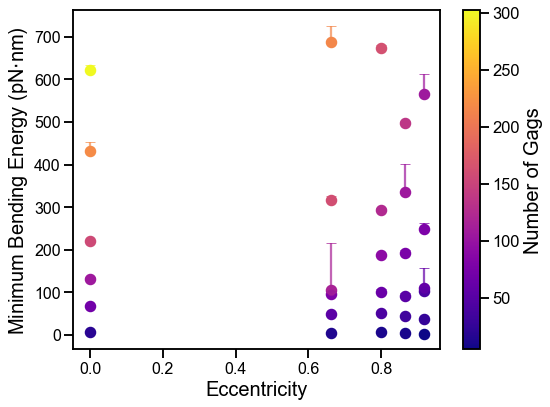

In [33]:
# Create colormap
unique_ngags = grouped_df['Ngags'].unique()
norm = mcolors.Normalize(vmin=min(unique_ngags), vmax=max(unique_ngags))
cmap = cm.plasma

plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
for ngags in unique_ngags:
    subset = grouped_df[grouped_df['Ngags'] == ngags]
    plt.scatter(subset['Ecc'], subset['EB'],
             s=100, color=cmap(norm(ngags)))
    
    # Add directed error bars (only top half)
    plt.errorbar(subset['Ecc'], subset['EB'], yerr=[np.zeros_like(subset['EB_err']), subset['EB_err']], 
                 fmt='o', capsize=5, color=cmap(norm(ngags)), alpha=0.7)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Number of Gags", fontsize=20, fontname='Arial')

# Labels and title
plt.xlabel("Eccentricity", fontsize=20, fontname='Arial')
plt.ylabel(r"Minimum Bending Energy (pN$\cdot$nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'EB_vs_Ecc_by_Ngags.svg'), format='svg')

plt.show()


Without any boundary size, extend volume to infinite, bending energy falls to zero.